<a href="https://colab.research.google.com/github/AdityaWarrier2006/TensorFlow-for-Machine-Learning/blob/main/02_03_neural_network_classification_with_tensorflow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import tensorflow as tf

In [2]:
# function made in 02_01 notebook

import matplotlib.pyplot as plt
import numpy as np

def plot_decision_boundary(model,x,y):
  # plots the decision boundary created by a model predicting on x.

  # define axis boundaries of plot and create meshgrid
  x_min, x_max = x[:, 0].min()-0.1, x[:,0].max()+0.1 # 0.1 is to have breathing room for the min and max points
  y_min, y_max = x[:, 1].min()-0.1, x[:,1].max()+0.1 # Corrected y_min, y_max to use x[:,1]

  # Create a meshgrid from both linspace arrays
  xx, yy = np.meshgrid(np.linspace(x_min, x_max, 100), np.linspace(y_min, y_max, 100))

  # create x values to make predictions on
  x_in = np.c_[xx.ravel(), yy.ravel()] # np.c_ is a shorthand for the actual funct

  # Make predictions (these will be logits since the last layer is Dense(1) without activation)
  y_pred = model.predict(x_in)

  # check for multi-class (multiple labes for a single input)
  if len(y_pred[0]) > 1:
    print("doing multiclass classification")
    # we have to reshape our predictions to get it ready for plotting
    y_pred = np.argmax(y_pred,axis=1).reshape(xx.shape)
  else:
    print("doing binary classification")
    y_pred = np.round(y_pred).reshape(xx.shape)

  plot_data = y_pred

  # plot the decision boundary
  plt.contourf(xx,yy, plot_data.reshape(xx.shape), cmap = plt.cm.RdYlBu, alpha = 0.7)
  plt.scatter(x[:,0], x[:,1], c = y, s = 40, cmap = plt.cm.RdYlBu)
  plt.xlim(xx.min(), xx.max())
  plt.ylim(yy.min(), yy.max())
  plt.show() # Ensure plot is displayed

In [3]:
from sklearn.datasets import make_circles

# make 1000 examples
n_samples = 1000

# create circles
x, y = make_circles(n_samples,
                    noise = 0.03)

In [4]:
# split x,y to training and testing
x_train, y_train = x[:800], y[:800]
x_test, y_test = x[800:], y[800:]

x_train.shape, x_test.shape, y_train.shape, y_test.shape

((800, 2), (200, 2), (800,), (200,))

In [5]:
model_10 = tf.keras.Sequential([
    tf.keras.layers.Dense(4, activation="relu", input_shape = [2,]),
    tf.keras.layers.Dense(4, activation="relu"),
    tf.keras.layers.Dense(1, activation = "sigmoid")
])

model_10.compile(loss = "BinaryCrossentropy",
                optimizer = tf.keras.optimizers.Adam(learning_rate = 0.02),
                metrics = ["accuracy"])

history_model_10 = model_10.fit(x_train, y_train, epochs = 25, verbose = 0)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [6]:
model_10.evaluate(x_test, y_test)

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.9100 - loss: 0.2555  


[0.25549551844596863, 0.9100000262260437]

In [7]:
'''
Model evaluation parameters
1. accuracy
2. precision
3. recall
4. f1-score
5. confusion matrix - sklearn.metrics.confusion_matrix()
6. classification report (from scikit-learn)
'''

'\nModel evaluation parameters\n1. accuracy\n2. precision\n3. recall\n4. f1-score\n5. confusion matrix - sklearn.metrics.confusion_matrix()\n6. classification report (from scikit-learn)\n'

Confusion Matrix

In [8]:
y_test[:5]

array([1, 1, 0, 1, 0])

In [9]:
# make preds
y_preds = model_10.predict(x_test)
y_preds[:5]

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 


array([[9.1327733e-01],
       [9.7686291e-01],
       [2.1166081e-02],
       [4.0633163e-01],
       [9.3171804e-04]], dtype=float32)

In [10]:
'''
y_test is in binary and y_preds is in logits
our preds have come out in prediction probability
we cannot create a confusion matrix while they are in different forms
we will convert our preds array to binary
'''

'\ny_test is in binary and y_preds is in logits\nour preds have come out in prediction probability\nwe cannot create a confusion matrix while they are in different forms\nwe will convert our preds array to binary\n'

In [11]:
# converting our prediction probability to binary format
# use round function from tensorflow

y_preds = tf.round(y_preds)
y_preds[:5]

<tf.Tensor: shape=(5, 1), dtype=float32, numpy=
array([[1.],
       [1.],
       [0.],
       [0.],
       [0.]], dtype=float32)>

In [12]:
from sklearn.metrics import confusion_matrix

# create confusion matrix
confusion_matrix(y_test, y_preds)
# Classification metrics can't handle a mix of binary and continuous targets

array([[90,  9],
       [ 9, 92]])

Prettify-ing our confusion matrix

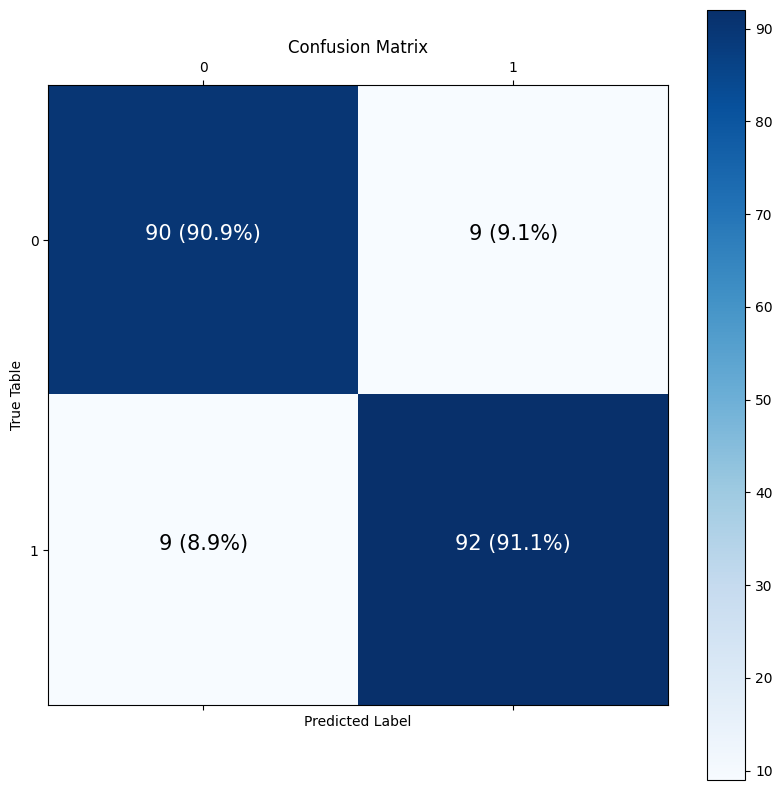

In [13]:
# the confusion matrix code we're about to write is a remix of scikit-learn's plot_confusion_matrix

import itertools

figsize = (10,10)

# create confusion matrix
cm  = confusion_matrix(y_test, y_preds)
cm_norm = cm.astype("float") / cm.sum(axis =1)[:, np.newaxis] # to normalize our confusion matrix
n_class = cm.shape[0]

# lets prettify it
fig, ax = plt.subplots(figsize = figsize)

# create a matrix plot
cax = ax.matshow(cm, cmap = plt.cm.Blues)
fig.colorbar(cax)

# create clases
classes = False

if classes:
  labels = classes
else:
  labels = np.arange(cm.shape[0]) # Corrected typo: arrange -> arange

# label the axes
ax.set(title = "Confusion Matrix",
       xlabel = "Predicted Label",
       ylabel = "True Table",
       xticks = np.arange(n_class),
       yticks = np.arange(n_class), # Removed extra comma
       xticklabels = labels,
       yticklabels = labels)

# set thresholds for different colors
threshold = (cm.max() + cm.min()) / 2

# plot the text on the cells
for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
  plt.text(j, i, f"{cm[i,j]} ({cm_norm[i, j]*100:.1f}%)", # Corrected f-string concatenation
  horizontalalignment = "center",
  color = "white" if cm[i,j] > threshold else "black",
           size = 15)